# 03 - ToF LiDAR Link Budget and Detection Simulation

This notebook connects emitted pulse energy, geometric return loss, detector
photoelectrons, background noise, threshold detection, and ROC curves.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src import plotting

plotting.set_style()
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

from scipy.stats import norm
from src import noise
from src.detector import LidarParams, lidar_return_energy, photoelectrons_from_energy, gaussian_threshold_detection

## 1. Engineering Problem

Estimate whether a pulsed ToF LiDAR can detect a diffuse target at range while
controlling false alarms. The industrial questions are:

- How many return photoelectrons are available versus distance?
- How do aperture, beam divergence, and target reflectivity affect range?
- How does sunlight/background power change detection probability?
- What threshold gives an acceptable false positive rate?
- Where does the link budget fail?

## 2. Physical Assumptions

- A single emitted optical pulse has fixed energy and wavelength.
- Large diffuse targets follow an approximate `R^-2` return scaling.
- Small targets smaller than the beam footprint add beam-interception loss and
  tend toward `R^-4` scaling.
- Detector output is modeled in photoelectrons per range gate.
- Background, dark current, and read noise are approximated as Gaussian electron
  noise for threshold detection.
- Timing walk, afterpulsing, speckle, and eye-safety limits are outside this
  compact model but should be added for a product design.

## 3. System Parameters

In [2]:
params = LidarParams(
    wavelength_m=905e-9,
    pulse_energy_j=20e-9,
    aperture_diameter_m=25e-3,
    receiver_efficiency=0.45,
    detector_quantum_efficiency=0.65,
    beam_divergence_rad=2.0e-3,
    target_reflectivity=0.25,
    target_area_m2=0.1,
    atmospheric_transmission=0.95,
)

gate_time_s = 8e-9
dark_current_a = 4e-9
read_noise_e = 6.0
background_power_w = 80e-9

pd.DataFrame(
    [
        ("wavelength_m", params.wavelength_m, "m", "905 nm is common for silicon-detector automotive/industrial LiDAR."),
        ("pulse_energy_j", params.pulse_energy_j, "J", "Optical energy emitted per pulse."),
        ("aperture_diameter_m", params.aperture_diameter_m, "m", "Receiver aperture; collected return scales with area."),
        ("beam_divergence_rad", params.beam_divergence_rad, "rad", "Sets beam footprint and small-target interception."),
        ("target_reflectivity", params.target_reflectivity, "fraction", "Diffuse reflectivity of the target."),
        ("gate_time_s", gate_time_s, "s", "Detection integration window around expected time of flight."),
        ("background_power_w", background_power_w, "W", "Background optical power admitted during the gate."),
        ("read_noise_e", read_noise_e, "e RMS", "Input-referred read/electronics noise per gate."),
    ],
    columns=["parameter", "value", "unit", "engineering meaning"],
)

,parameter,value,unit,engineering meaning
0,wavelength_m,9.050000e-07,m,905 nm is common for silicon-detector automoti...
1,pulse_energy_j,2.000000e-08,J,Optical energy emitted per pulse.
2,aperture_diameter_m,2.500000e-02,m,Receiver aperture; collected return scales wit...
3,beam_divergence_rad,2.000000e-03,rad,Sets beam footprint and small-target intercept...
4,target_reflectivity,2.500000e-01,fraction,Diffuse reflectivity of the target.
5,gate_time_s,8.000000e-09,s,Detection integration window around expected t...
6,background_power_w,8.000000e-08,W,Background optical power admitted during the g...
7,read_noise_e,6.000000e+00,e RMS,Input-referred read/electronics noise per gate.


## 4. Simulation Model

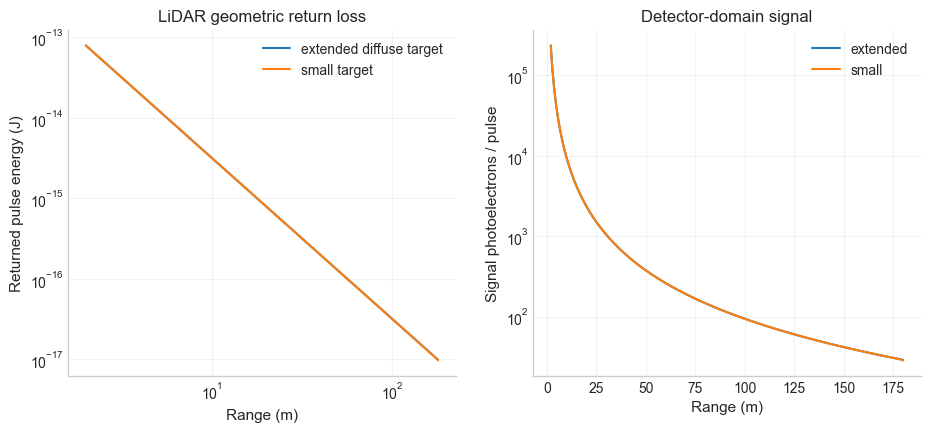

In [3]:
ranges_m = np.linspace(2, 180, 400)
energy_extended = lidar_return_energy(ranges_m, params, model="diffuse_extended")
energy_small = lidar_return_energy(ranges_m, params, model="small_target")
electrons_extended = photoelectrons_from_energy(energy_extended, params.wavelength_m, params.detector_quantum_efficiency)
electrons_small = photoelectrons_from_energy(energy_small, params.wavelength_m, params.detector_quantum_efficiency)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].loglog(ranges_m, energy_extended, label="extended diffuse target")
axes[0].loglog(ranges_m, energy_small, label="small target")
axes[0].set_xlabel("Range (m)")
axes[0].set_ylabel("Returned pulse energy (J)")
axes[0].set_title("LiDAR geometric return loss")
axes[0].legend()

axes[1].semilogy(ranges_m, electrons_extended, label="extended")
axes[1].semilogy(ranges_m, electrons_small, label="small")
axes[1].set_xlabel("Range (m)")
axes[1].set_ylabel("Signal photoelectrons / pulse")
axes[1].set_title("Detector-domain signal")
axes[1].legend()
plt.show()

## 5. Noise / Uncertainty Model

For one range gate:

- Background electrons: `P_bg t_gate / E_photon * QE`
- Dark electrons: `I_dark t_gate / q`
- Total noise sigma: `sqrt(background + dark + read_noise^2)`

The threshold detector compares measured electrons against a threshold. A lower
threshold improves sensitivity but increases false positives.

In [4]:
background_e = photoelectrons_from_energy(background_power_w * gate_time_s, params.wavelength_m, params.detector_quantum_efficiency)
dark_e = dark_current_a * gate_time_s / noise.Q_E
noise_sigma_e = np.sqrt(background_e + dark_e + read_noise_e**2)
target_false_alarm = 1e-4
threshold_e = noise_sigma_e * norm.isf(target_false_alarm)

snr_extended = electrons_extended / np.sqrt(electrons_extended + background_e + dark_e + read_noise_e**2)
detection_probability = norm.sf((threshold_e - electrons_extended) / noise_sigma_e)

pd.DataFrame(
    [
        ("background_e", background_e, "e/gate", "Sunlight/background contribution."),
        ("dark_e", dark_e, "e/gate", "Dark-current charge during gate."),
        ("noise_sigma_e", noise_sigma_e, "e RMS", "Gaussian threshold-noise approximation."),
        ("threshold_e", threshold_e, "e", "Threshold chosen for 1e-4 false alarm probability."),
    ],
    columns=["quantity", "value", "unit", "meaning"],
)

,quantity,value,unit,meaning
0,background_e,1895.244205,e/gate,Sunlight/background contribution.
1,dark_e,199.728290,e/gate,Dark-current charge during gate.
2,noise_sigma_e,46.162458,e RMS,Gaussian threshold-noise approximation.
3,threshold_e,171.678941,e,Threshold chosen for 1e-4 false alarm probabil...


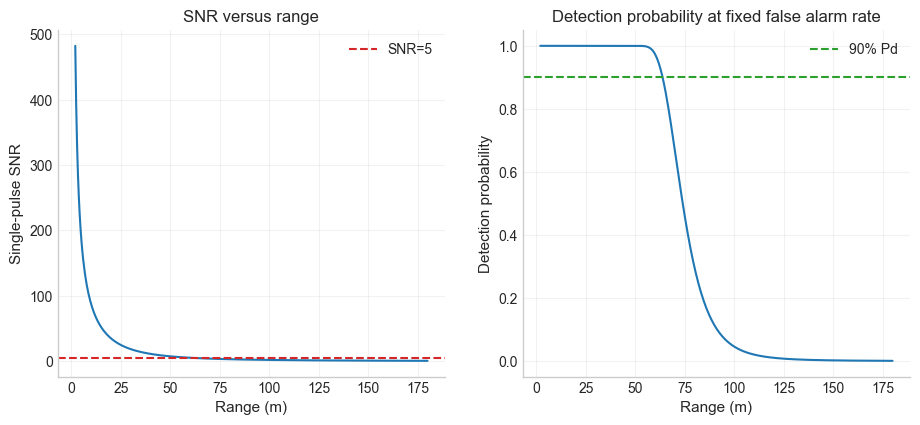

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(ranges_m, snr_extended)
axes[0].axhline(5, color="tab:red", ls="--", label="SNR=5")
axes[0].set_xlabel("Range (m)")
axes[0].set_ylabel("Single-pulse SNR")
axes[0].set_title("SNR versus range")
axes[0].legend()

axes[1].plot(ranges_m, detection_probability)
axes[1].axhline(0.9, color="tab:green", ls="--", label="90% Pd")
axes[1].set_xlabel("Range (m)")
axes[1].set_ylabel("Detection probability")
axes[1].set_title("Detection probability at fixed false alarm rate")
axes[1].legend()
plt.show()

## 6. Parameter Scan

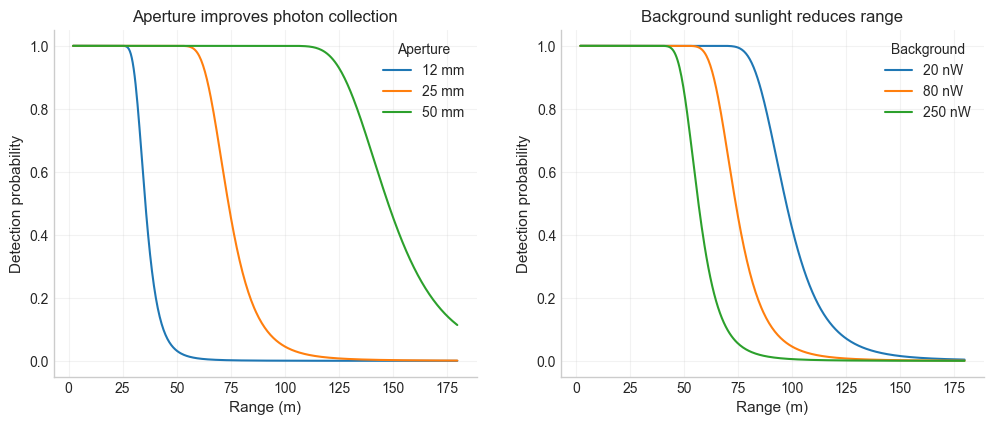

In [6]:
apertures_mm = [12, 25, 50]
backgrounds_nw = [20, 80, 250]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for aperture_mm in apertures_mm:
    p = LidarParams(**{**params.__dict__, "aperture_diameter_m": aperture_mm * 1e-3})
    signal_e = photoelectrons_from_energy(
        lidar_return_energy(ranges_m, p), p.wavelength_m, p.detector_quantum_efficiency
    )
    pd_range = norm.sf((threshold_e - signal_e) / noise_sigma_e)
    axes[0].plot(ranges_m, pd_range, label=f"{aperture_mm} mm")
axes[0].set_xlabel("Range (m)")
axes[0].set_ylabel("Detection probability")
axes[0].set_title("Aperture improves photon collection")
axes[0].legend(title="Aperture")

for bg_nw in backgrounds_nw:
    bg_e = photoelectrons_from_energy(bg_nw * 1e-9 * gate_time_s, params.wavelength_m, params.detector_quantum_efficiency)
    sigma = np.sqrt(bg_e + dark_e + read_noise_e**2)
    threshold = sigma * norm.isf(target_false_alarm)
    pd_range = norm.sf((threshold - electrons_extended) / sigma)
    axes[1].plot(ranges_m, pd_range, label=f"{bg_nw} nW")
axes[1].set_xlabel("Range (m)")
axes[1].set_ylabel("Detection probability")
axes[1].set_title("Background sunlight reduces range")
axes[1].legend(title="Background")
plt.show()

## 7. Failure Regime

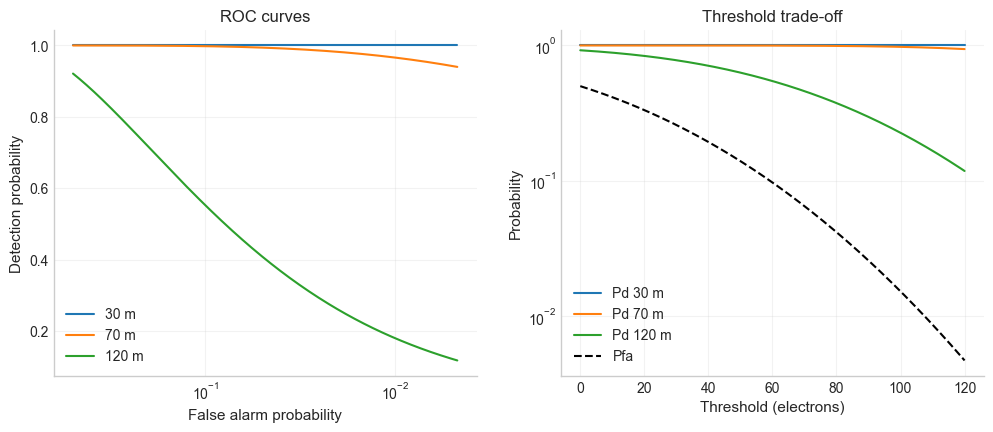

In [7]:
thresholds = np.linspace(0, 120, 300)
ranges_for_roc = [30, 70, 120]
signals_for_roc = np.interp(ranges_for_roc, ranges_m, electrons_extended)
metrics = gaussian_threshold_detection(signals_for_roc, noise_sigma_e, thresholds)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for idx, range_value in enumerate(ranges_for_roc):
    axes[0].semilogx(
        metrics["false_alarm_probability"],
        metrics["detection_probability"][idx],
        label=f"{range_value} m",
    )
axes[0].invert_xaxis()
axes[0].set_xlabel("False alarm probability")
axes[0].set_ylabel("Detection probability")
axes[0].set_title("ROC curves")
axes[0].legend()

for idx, range_value in enumerate(ranges_for_roc):
    axes[1].plot(thresholds, metrics["detection_probability"][idx], label=f"Pd {range_value} m")
axes[1].plot(thresholds, metrics["false_alarm_probability"], "k--", label="Pfa")
axes[1].set_yscale("log")
axes[1].set_xlabel("Threshold (electrons)")
axes[1].set_ylabel("Probability")
axes[1].set_title("Threshold trade-off")
axes[1].legend()
plt.show()

## 8. Design Trade-Off

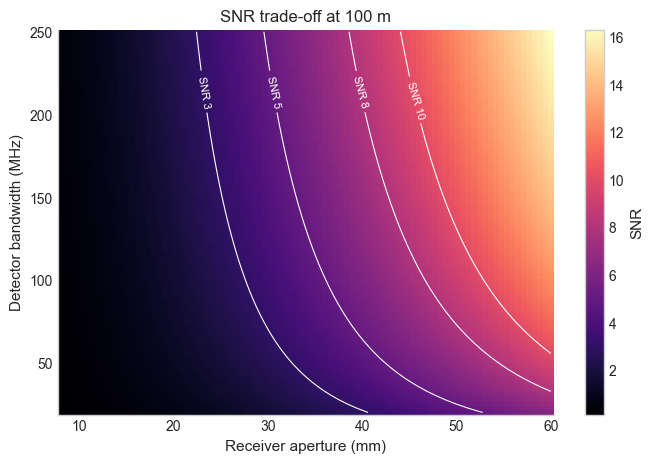

In [8]:
aperture_grid_mm = np.linspace(8, 60, 90)
bandwidth_grid_mhz = np.linspace(20, 250, 90)
range_target_m = 100
snr_map = np.empty((len(bandwidth_grid_mhz), len(aperture_grid_mm)))

for i, bandwidth_mhz in enumerate(bandwidth_grid_mhz):
    gate = 1.0 / (2 * bandwidth_mhz * 1e6)
    for j, aperture_mm in enumerate(aperture_grid_mm):
        p = LidarParams(**{**params.__dict__, "aperture_diameter_m": aperture_mm * 1e-3})
        sig_e = photoelectrons_from_energy(lidar_return_energy(range_target_m, p), p.wavelength_m, p.detector_quantum_efficiency)
        bg_e = photoelectrons_from_energy(background_power_w * gate, p.wavelength_m, p.detector_quantum_efficiency)
        dark_gate_e = dark_current_a * gate / noise.Q_E
        snr_map[i, j] = sig_e / np.sqrt(sig_e + bg_e + dark_gate_e + read_noise_e**2)

fig, ax = plt.subplots(figsize=(8, 5))
mesh = ax.pcolormesh(aperture_grid_mm, bandwidth_grid_mhz, snr_map, shading="auto", cmap="magma")
contours = ax.contour(aperture_grid_mm, bandwidth_grid_mhz, snr_map, levels=[3, 5, 8, 10], colors="white", linewidths=0.8)
ax.clabel(contours, fmt="SNR %.0f", fontsize=8)
ax.set_xlabel("Receiver aperture (mm)")
ax.set_ylabel("Detector bandwidth (MHz)")
ax.set_title(f"SNR trade-off at {range_target_m} m")
fig.colorbar(mesh, ax=ax, label="SNR")
plt.show()

## 9. Key Engineering Conclusions

- Range performance is fundamentally photon-limited: aperture area, pulse energy,
  target reflectivity, and atmospheric loss directly set the return electrons.
- Large diffuse targets and small targets can have very different range scaling;
  using the wrong model can overstate range.
- A threshold must be selected with both detection probability and false alarm
  rate in mind; ROC curves are more informative than one SNR number.
- Background sunlight raises the noise floor and threshold, reducing useful range.
- Larger aperture improves SNR but increases cost, size, alignment sensitivity,
  and stray-light management.
- Wider bandwidth improves timing resolution but shortens the gate and can raise
  receiver noise requirements, so bandwidth must be co-designed with timing specs.